In [1]:
%%capture
!apt install python-opengl -y
!apt install ffmpeg -y
!apt install xvfb -y
!pip install pyvirtualdisplay
!pip install pyglet==1.5.1

In [2]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

In [3]:
!pip install gymnasium[mujoco] stable-baselines3==2.2.1

In [4]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

from IPython.display import HTML, Video
from base64 import b64encode

In [5]:
class DiscretizedActionWrapper(gym.ActionWrapper):
    def __init__(self, env, bins=3):
        super().__init__(env)
        self.bins = bins
        self.low = env.action_space.low
        self.high = env.action_space.high
        self.n_actions = bins ** env.action_space.shape[0]

        self.action_space = gym.spaces.Discrete(self.n_actions)
        self.discrete_actions = self.create_action_grid()

    def create_action_grid(self):
        grids = [np.linspace(l, h, self.bins) for l, h in zip(self.low, self.high)]
        mesh = np.meshgrid(*grids)
        combos = np.stack(mesh, axis=-1).reshape(-1, len(self.low))
        return combos

    def action(self, action_idx):
        return self.discrete_actions[action_idx]

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return (
            torch.tensor(state, dtype=torch.float32),
            torch.tensor(action, dtype=torch.int64),
            torch.tensor(reward, dtype=torch.float32),
            torch.tensor(next_state, dtype=torch.float32),
            torch.tensor(done, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


In [7]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, act_dim)
        )

    def forward(self, x):
        return self.net(x)


In [8]:
class DQNAgent:
    def __init__(self, obs_dim, act_dim, device):
        self.q_net = QNetwork(obs_dim, act_dim).to(device)
        self.target_q_net = QNetwork(obs_dim, act_dim).to(device)
        self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.target_q_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=1e-3)
        self.criteria = nn.SmoothL1Loss()  #
        self.device = device
        self.act_dim = act_dim

    def act(self, obs, epsilon):
        if random.random() < epsilon:
            return random.randint(0, self.act_dim - 1)
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_vals = self.q_net(obs_tensor)
        return q_vals.argmax().item()

    def update(self, buffer, batch_size, gamma):
        if len(buffer) < batch_size:
            return None

        obs, act, rew, next_obs, done = buffer.sample(batch_size)
        obs = obs.to(self.device)
        act = act.to(self.device)
        rew = rew.to(self.device)
        next_obs = next_obs.to(self.device)
        done = done.to(self.device)

        q_vals = self.q_net(obs).gather(1, act.unsqueeze(1)).squeeze()

        with torch.no_grad():
            next_q_vals = self.target_q_net(next_obs).max(1)[0]
            target_q = rew + gamma * (1 - done) * next_q_vals

        loss = self.criteria(q_vals, target_q)

        self.optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)

        self.optimizer.step()

        return loss.item()




In [9]:
env_id = "HalfCheetah-v4"
env = DiscretizedActionWrapper(gym.make(env_id, render_mode="rgb_array"), bins=3)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n

buffer = ReplayBuffer(100_000)
agent = DQNAgent(obs_dim, act_dim, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.05
gamma = 0.99
batch_size = 256
target_update_freq = 1000

rewards = []
lengths = []
losses = []
total_steps = 0
max_steps = 200_000

obs, _ = env.reset(seed=42)

pbar = tqdm(total=max_steps, desc="Training DQN")

while total_steps < max_steps:
    ep_reward = 0
    ep_len = 0
    done = False

    while not done:
        action = agent.act(obs, epsilon)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(obs, action, reward, next_obs, done)

        loss = agent.update(buffer, batch_size, gamma)
        if loss is not None:
            losses.append(loss)

        obs = next_obs
        ep_reward += reward
        ep_len += 1
        total_steps += 1
        pbar.update(1)

        if total_steps % target_update_freq == 0:
            agent.target_q_net.load_state_dict(agent.q_net.state_dict())

        if total_steps >= max_steps:
            break


    rewards.append(ep_reward)
    lengths.append(ep_len)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    obs, _ = env.reset()
pbar.close()
env.close()

torch.save(agent.q_net.state_dict(), "dqn_halfcheetah.pt")


Training DQN: 100%|██████████| 200000/200000 [1:13:16<00:00, 45.49it/s]


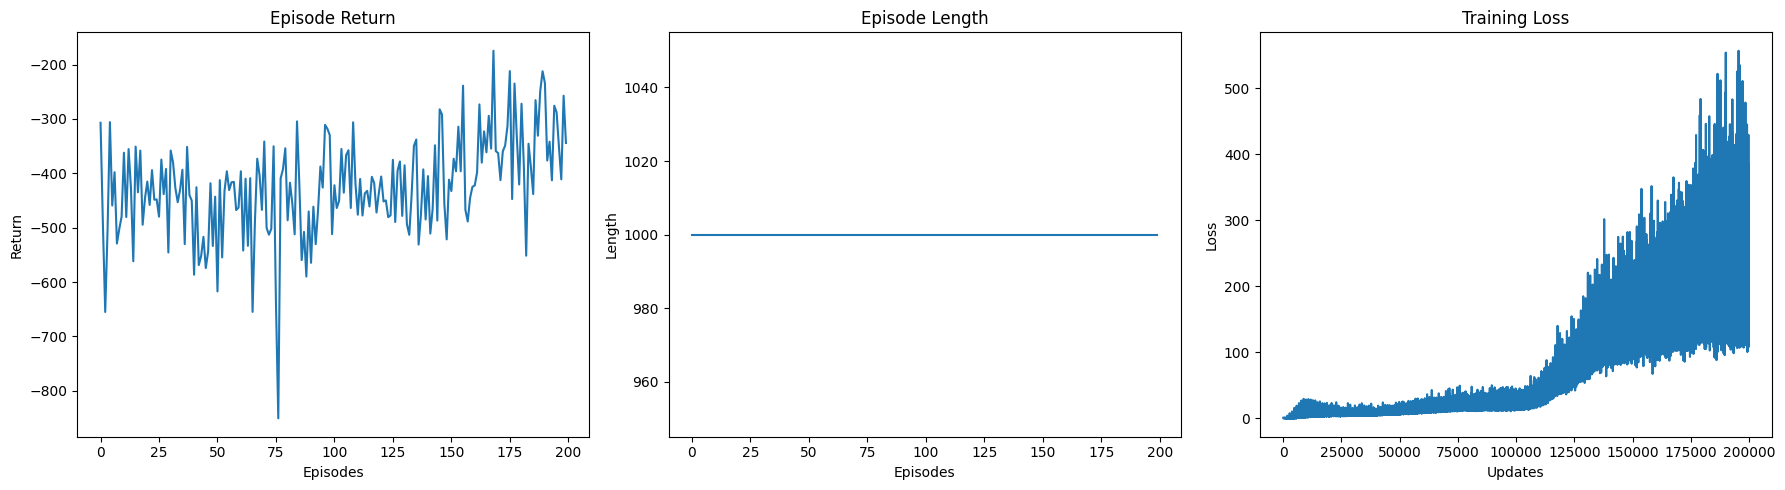

In [10]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(rewards)
plt.title("Episode Return")
plt.xlabel("Episodes")
plt.ylabel("Return")

plt.subplot(1, 3, 2)
plt.plot(lengths)
plt.title("Episode Length")
plt.xlabel("Episodes")
plt.ylabel("Length")

plt.subplot(1, 3, 3)
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Updates")
plt.ylabel("Loss")

plt.tight_layout()
plt.savefig("dqn_halfcheetah_metrics_with_loss.png")
plt.show()



In [27]:
def normalize(array):
    array = np.array(array)
    return (array - array.min()) / (array.max() - array.min() + 1e-8)




In [28]:
# Normalize each metric
dqn_rewards = normalize(rewards)
dqn_lengths = normalize(lengths)
dqn_losses = normalize(losses)


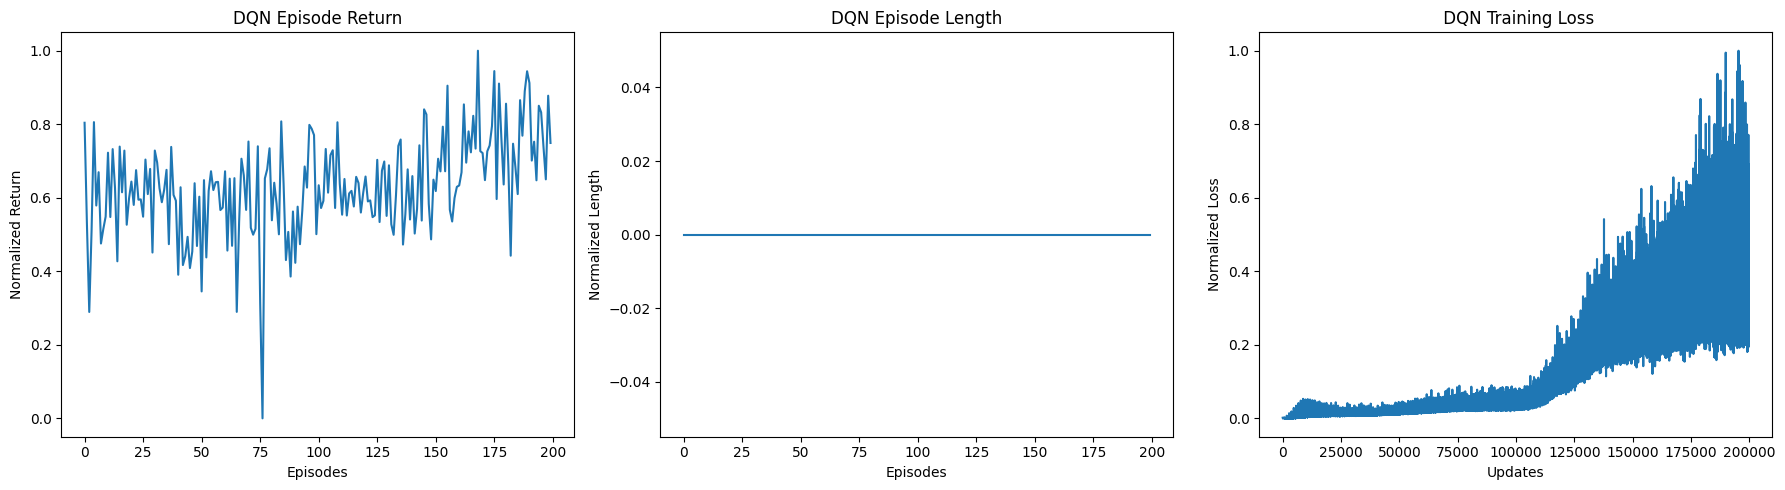

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(dqn_rewards)
plt.title("DQN Episode Return")
plt.xlabel("Episodes")
plt.ylabel("Normalized Return")

plt.subplot(1, 3, 2)
plt.plot(dqn_lengths)
plt.title("DQN Episode Length")
plt.xlabel("Episodes")
plt.ylabel("Normalized Length")

plt.subplot(1, 3, 3)
plt.plot(dqn_losses)
plt.title(" DQN Training Loss")
plt.xlabel("Updates")
plt.ylabel("Normalized Loss")

plt.tight_layout()
plt.savefig("dqn_halfcheetah_metrics_normalized.png")
plt.show()


In [11]:
def record_video(env_id, q_net_path, video_path="dqn_eval.mp4", steps=1000):
    env = DiscretizedActionWrapper(gym.make(env_id, render_mode="rgb_array"), bins=3)
    q_net = QNetwork(env.observation_space.shape[0], env.action_space.n)
    q_net.load_state_dict(torch.load(q_net_path, map_location="cpu"))
    q_net.eval()

    obs, _ = env.reset(seed=123)
    frames = []

    for _ in range(steps):
        frame = env.render()
        frames.append(frame)
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            action = q_net(obs_tensor).argmax().item()
        obs, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
    env.close()

    import imageio
    imageio.mimsave(video_path, frames, fps=30)

record_video("HalfCheetah-v4", "dqn_halfcheetah.pt")

# Display in Colab
mp4 = open("dqn_eval.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=640 controls><source src="{data_url}" type="video/mp4"></video>')


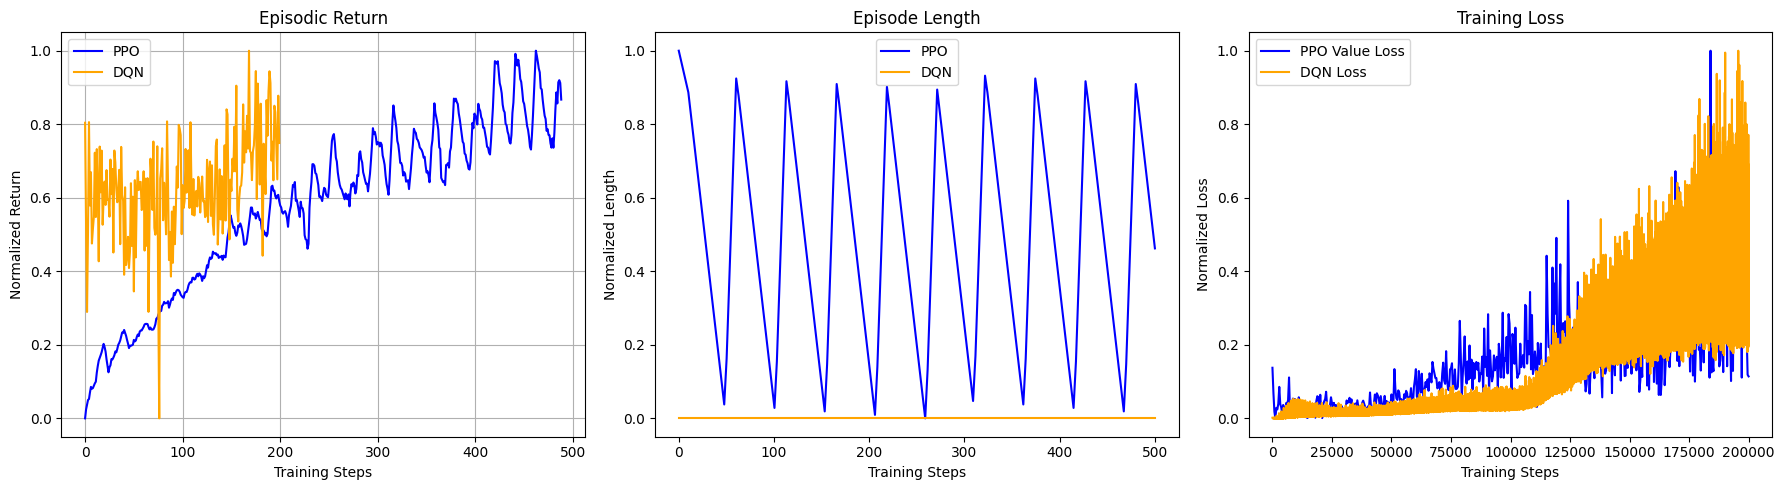

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_y(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

# Load PPO data
ppo_returns = np.load("returns_norm.npy")
ppo_lengths = np.load("lengths_norm.npy")
ppo_value_loss = np.load("value_loss_norm.npy")

# Load DQN data
dqn_rewards = normalize(rewards)
dqn_lengths = normalize(lengths)
dqn_losses = normalize(losses)

x_episode = np.linspace(0, 500, min(len(ppo_returns), len(dqn_rewards)))
x_loss_dqn = np.linspace(0, 200_000, len(dqn_losses))
x_loss_ppo = np.linspace(0, 200_000, len(ppo_value_loss))

# Plot comparison
plt.figure(figsize=(18, 5))

# Return Comparison
plt.subplot(1, 3, 1)
plt.plot(ppo_returns, label="PPO", color='blue')
plt.plot(dqn_rewards, label="DQN", color='orange')
plt.title("Episodic Return")
plt.xlabel("Training Steps")
plt.ylabel("Normalized Return")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x_episode, ppo_lengths[:len(x_episode)], label="PPO", color="blue")
plt.plot(x_episode, dqn_lengths[:len(x_episode)], label="DQN", color="orange")
plt.title("Episode Length")
plt.xlabel("Training Steps")
plt.ylabel("Normalized Length")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(x_loss_ppo, ppo_value_loss, label="PPO Value Loss", color="blue")
plt.plot(x_loss_dqn, dqn_losses, label="DQN Loss", color="orange")
plt.title("Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Normalized Loss")
plt.legend()

plt.tight_layout()
plt.savefig("ppo_vs_dqn_comparison.png")
plt.show()
